In [19]:
%pip install pandas numpy seaborn matplotlib scikit-learn

  Using cached scikit_learn-1.9.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.2 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new releas

In [2]:
import pandas as pd

# Visão geral do dataset

In [3]:
# Load the dataset
df = pd.read_csv("./data/dados_clientes.csv")

In [4]:
df.head()

,id_cliente,nome,idade,genero,renda_anual,categoria_produto,valor_compra,data_compra,regiao
0,1006,Gabriela Rocha,40.0,Masculino,750000.000000,Eletrônicos,1084.904523,2024-01-15,Centro-Oeste
1,1019,Isabela Martins,42.0,Outro,174931.504986,Casa,984.100186,2024-04-05,Norte
2,1014,Gabriela Rocha,33.0,Outro,180660.619728,Moda,2017.981504,2024/03/10,Norte
3,1010,Sabrina Torres,58.0,Feminino,95133.980567,Esporte,4981.455814,2024/03/10,Nordeste
4,1007,Daniel Costa,42.0,Outro,96879.401953,Beleza,2052.315229,2024-06-22,Centro-Oeste


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         30 non-null     int64  
 1   nome               30 non-null     str    
 2   idade              28 non-null     float64
 3   genero             30 non-null     str    
 4   renda_anual        29 non-null     float64
 5   categoria_produto  30 non-null     str    
 6   valor_compra       28 non-null     float64
 7   data_compra        26 non-null     str    
 8   regiao             30 non-null     str    
dtypes: float64(3), int64(1), str(5)
memory usage: 2.2 KB


# Limpeza de dados

## Tratando valores nulos

In [6]:
# Verifica valores nulos
print(df.isnull().sum())

# Remove valores nulos
df = df.dropna()

id_cliente           0
nome                 0
idade                2
genero               0
renda_anual          1
categoria_produto    0
valor_compra         2
data_compra          4
regiao               0
dtype: int64


## Tratando valores duplicados

In [7]:
# Verifica valores duplicados
df.duplicated().sum()

np.int64(0)

# Analisando e tratando outliers

In [8]:
def detect_outliers_iqr(data: pd.DataFrame, column: str) -> pd.DataFrame:
    """Função para detectar outliers usando o método do IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

## Visualizando outliers

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

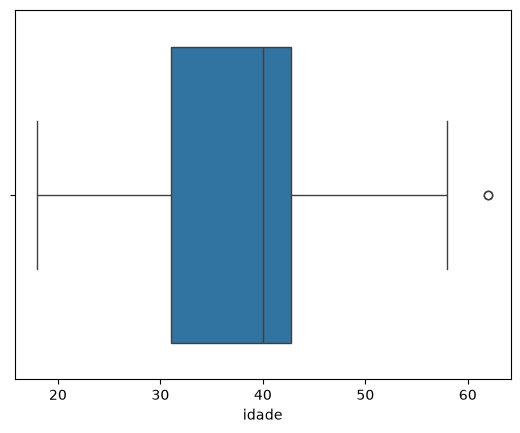

In [10]:
sns.boxplot(x=df['idade'])
plt.show()

In [11]:
# Detectando outliers na coluna 'idade'
outliers_idade = detect_outliers_iqr(df, "idade")
print(f"Outliers na coluna 'idade': {len(outliers_idade)}")

Outliers na coluna 'idade': 2


In [13]:
# Detectando outliers na coluna 'renda_anual'
outliers_renda_anual = detect_outliers_iqr(df, "renda_anual")
print(f"Outliers na coluna 'renda_anual': {len(outliers_renda_anual)}")

Outliers na coluna 'renda_anual': 2


In [15]:
# Detectando outliers na coluna 'valor_compra'
outliers_valor_compra = detect_outliers_iqr(df, "valor_compra")
print(f"Outliers na coluna 'valor_compra': {len(outliers_valor_compra)}")

Outliers na coluna 'valor_compra': 0


In [17]:
# Remove outliers
df = df[~df.isin(outliers_idade.to_dict("records")).any(axis=1)]
df = df[~df.isin(outliers_renda_anual.to_dict("records")).any(axis=1)]
df = df[~df.isin(outliers_valor_compra.to_dict("records")).any(axis=1)]

# Normalização de dados e encoding de variáveis categóricas

In [22]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [31]:
numeric_cols = ["idade", "renda_anual", "valor_compra"]
categorical_cols = ["genero", "categoria_produto", "regiao"]

In [32]:
# Normalizando colunas numéricas
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df

,id_cliente,nome,idade,genero,renda_anual,categoria_produto,valor_compra,data_compra,regiao
0,1006,Gabriela Rocha,0.500000,Masculino,1.000000,Eletrônicos,0.025218,2024-01-15,Centro-Oeste
1,1019,Isabela Martins,0.545455,Outro,0.190262,Casa,0.000000,2024-04-05,Norte
2,1014,Gabriela Rocha,0.340909,Outro,0.198329,Moda,0.258641,2024/03/10,Norte
3,1010,Sabrina Torres,0.909091,Feminino,0.077901,Esporte,1.000000,2024/03/10,Nordeste
4,1007,Daniel Costa,0.545455,Outro,0.080359,Beleza,0.267230,2024-06-22,Centro-Oeste
5,1006,Natália Teixeira,0.500000,Feminino,0.190262,Moda,0.258641,2024-06-22,Sul
6,1018,Sabrina Torres,0.295455,Outro,0.207742,Beleza,0.267230,2024-06-22,Norte
7,1010,Isabela Martins,0.295455,Masculino,0.647982,Casa,0.738822,2024-06-22,Norte
9,1003,Vitor Azevedo,0.522727,Feminino,0.176755,Eletrônicos,0.406080,2024-06-22,Norte
11,1002,Gabriela Rocha,0.454545,Masculino,0.000000,Beleza,0.930988,2024/03/10,Centro-Oeste


In [37]:
# Encoding de variáveis categóricas
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[categorical_columns])
df_enc = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(categorical_columns))

In [38]:
df_enc.head()

,genero_Feminino,genero_Masculino,genero_Outro,regiao_Centro-Oeste,regiao_Nordeste,regiao_Norte,regiao_Sudeste,regiao_Sul
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


# Tratando datas

In [42]:
df["data_compra"] = pd.to_datetime(df["data_compra"], format="%Y-%m-%d", errors="coerce")

In [45]:
df["ano_compra"] = df["data_compra"].dt.year
df["mes_compra"] = df["data_compra"].dt.month
df["dia_compra"] = df["data_compra"].dt.day
df

,id_cliente,nome,idade,genero,renda_anual,categoria_produto,valor_compra,data_compra,regiao,ano_compra,mes_compra,dia_compra
0,1006,Gabriela Rocha,0.500000,Masculino,1.000000,Eletrônicos,0.025218,2024-01-15,Centro-Oeste,2024.0,1.0,15.0
1,1019,Isabela Martins,0.545455,Outro,0.190262,Casa,0.000000,2024-04-05,Norte,2024.0,4.0,5.0
2,1014,Gabriela Rocha,0.340909,Outro,0.198329,Moda,0.258641,NaT,Norte,NaN,NaN,NaN
3,1010,Sabrina Torres,0.909091,Feminino,0.077901,Esporte,1.000000,NaT,Nordeste,NaN,NaN,NaN
4,1007,Daniel Costa,0.545455,Outro,0.080359,Beleza,0.267230,2024-06-22,Centro-Oeste,2024.0,6.0,22.0
5,1006,Natália Teixeira,0.500000,Feminino,0.190262,Moda,0.258641,2024-06-22,Sul,2024.0,6.0,22.0
6,1018,Sabrina Torres,0.295455,Outro,0.207742,Beleza,0.267230,2024-06-22,Norte,2024.0,6.0,22.0
7,1010,Isabela Martins,0.295455,Masculino,0.647982,Casa,0.738822,2024-06-22,Norte,2024.0,6.0,22.0
9,1003,Vitor Azevedo,0.522727,Feminino,0.176755,Eletrônicos,0.406080,2024-06-22,Norte,2024.0,6.0,22.0
11,1002,Gabriela Rocha,0.454545,Masculino,0.000000,Beleza,0.930988,NaT,Centro-Oeste,NaN,NaN,NaN
